In [22]:
!pip install hmmlearn


In [23]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import yfinance as yf
from hmmlearn.hmm import GaussianHMM

## Momentum Based Trading Strategy

Using the last 10 years of daily stock price data for the Dow Jones 30, develop
and backtest two proprietary trading strategies, one based on the idea of
mean reversion, the other based on momentum. Provide an "Investment
Committee Memorandum" (ICM) that incorporates the following elements:
- A complete description of the strategy, including the rationale for it
- Conditions under which it should generate profits and conditions under
which it will lose money
- Statistical properties of the cash flows and returns
- Summary of the historical performance characteristics of the strategy
over the last 10 years

### Architecture Diagram

Suggested from Claude, so need to double check

#### DJIA Momentum Strategy — Model Pipeline
##### Stage 1 - Data Collection + Aggregation
- Bloomberg Data on DowJones over 10 years
- Risk Free rate for sharpe ratio calculations

##### Stage 2 — Signal Construction

- 12-1 momentum — 12mo return, skip last month
- Risk-adjusted momentum — momentum ÷ rolling volatility
- Volume momentum — signal × relative volume

##### Stage 3 — Signal Combination

- Lasso (L1) — zeros out weak signals
- Ridge (L2) — shrinks all weights evenly
- λ tuning — walk-forward CV, no shuffling

##### Stage 4 — Regime Filter (HMM)

- Bull — full momentum exposure
- High-vol — reduce position size
- Bear — turn off strategy

##### Stage 5 — Walk-Forward Backtest

- Train 2016–2022, test 2023–2026
- Portfolio — long top quintile / short bottom
- Costs — 5–10 bps per trade
- No look-ahead — signal on t, trade on t+1
- Metrics — Sharpe, Sortino, max drawdown, info ratio, skew/kurtosis

→ Investment Committee Memorandum

## Stage 1 - Data Collection

Using yahoo finance to get the historic data of the stocks within the Dow Jones.

In [24]:
BASELINE_APR2016 = {
    "AAPL", "AXP", "BA",  "CAT",  "CSCO", "CVX",  "DD",
    "DIS",  "GE",  "GS",  "HD",   "IBM",  "INTC", "JNJ",
    "JPM",  "KO",  "MCD", "MMM",  "MRK",  "MSFT", "NKE",
    "PFE",  "PG",  "RTX", "TRV",  "UNH",  "V",    "VZ",
    "WMT",  "XOM",
}

CHANGES = [
    ("2018-06-26", ["WBA"],               ["GE"]),
    ("2019-04-02", ["DOW"],               ["DD"]),
    ("2020-04-06", ["RTX"],               ["UTX"]),
    ("2020-08-31", ["AMGN","CRM","HON"],  ["XOM","PFE","RTX"]),
    ("2024-02-26", ["AMZN","SHW"],        ["WBA","INTC"]),
    ("2024-11-01", ["NVDA"],              ["DOW"]),
]

days = pd.bdate_range("2016-04-18", "2026-04-18")

current = set(BASELINE_APR2016)
changes_sorted = sorted(CHANGES, key=lambda x: pd.Timestamp(x[0]))
change_idx = 0
records = []

for day in days:
    while change_idx < len(changes_sorted):
        eff = pd.Timestamp(changes_sorted[change_idx][0])
        if eff <= day:
            _, added, removed = changes_sorted[change_idx]
            current.update(added)
            current -= set(removed)
            change_idx += 1
        else:
            break
    for ticker in sorted(current):
        records.append({"date": day, "ticker": ticker})

constituents = pd.DataFrame(records)

In [25]:
# ── Inputs ────────────────────────────────────────────────────────────────
# bloomberg_constituents : DataFrame with columns [date, ticker]
#                          one row per constituent per snapshot date

START_DATE = "2016-04-01"
END_DATE   = "2026-04-18"

# ── Build point-in-time constituent matrix ────────────────────────────────
bbg = constituents.copy()
bbg["date"] = pd.to_datetime(bbg["date"])

snapshots = {
    date: set(group["ticker"])
    for date, group in bbg.groupby("date")
}
snapshot_index = pd.DatetimeIndex(sorted(snapshots))
all_tickers    = sorted({t for s in snapshots.values() for t in s})
all_tickers = [t for t in all_tickers if t != "WBA"]
# ── Download prices and volume ─────────────────────────────────────────────
raw = yf.download(
    all_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True,
)

prices = raw["Close"]
volume = raw["Volume"]

# ── Risk-free rate ─────────────────────────────────────────────────────────
import pandas_datareader.data as web

rf_raw   = web.DataReader("DTB3", "fred", START_DATE, END_DATE).squeeze()
rf_daily = (rf_raw / 100) / 252
rf_daily = rf_daily.reindex(pd.date_range(START_DATE, END_DATE, freq="B")).ffill()

# ── Align prices to trading dates ─────────────────────────────────────────
prices = prices.sort_index()
volume = volume.sort_index()

# ── Build constituent map (trading-day resolution) ─────────────────────────
constituent_map = pd.DataFrame(False, index=prices.index, columns=all_tickers)

for date in prices.index:
    prior = snapshot_index[snapshot_index <= date]
    if prior.empty:
        continue
    for ticker in snapshots[prior[-1]]:
        if ticker in constituent_map.columns:
            constituent_map.loc[date, ticker] = True

# ── Clean prices ───────────────────────────────────────────────────────────
prices = prices.ffill(limit=10)
volume = volume.ffill(limit=10)

# ── Summary ────────────────────────────────────────────────────────────────
# print(f"Prices  : {prices.shape}")
# print(f"Volume  : {volume.shape}")
# print(f"RF rate : {rf_daily.shape}  avg {rf_daily.mean()*252*100:.2f}% annual")
# print(f"Const.  : {constituent_map.shape}  avg {constituent_map.sum(axis=1).mean():.1f} stocks/day")

[*********************100%***********************]  37 of 37 completed


### Visualization to Double Check

/tmp/ipykernel_3151/2852798820.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rf_daily_aligned = rf_daily.reindex(djia_daily_ret.index).fillna(method='ffill')


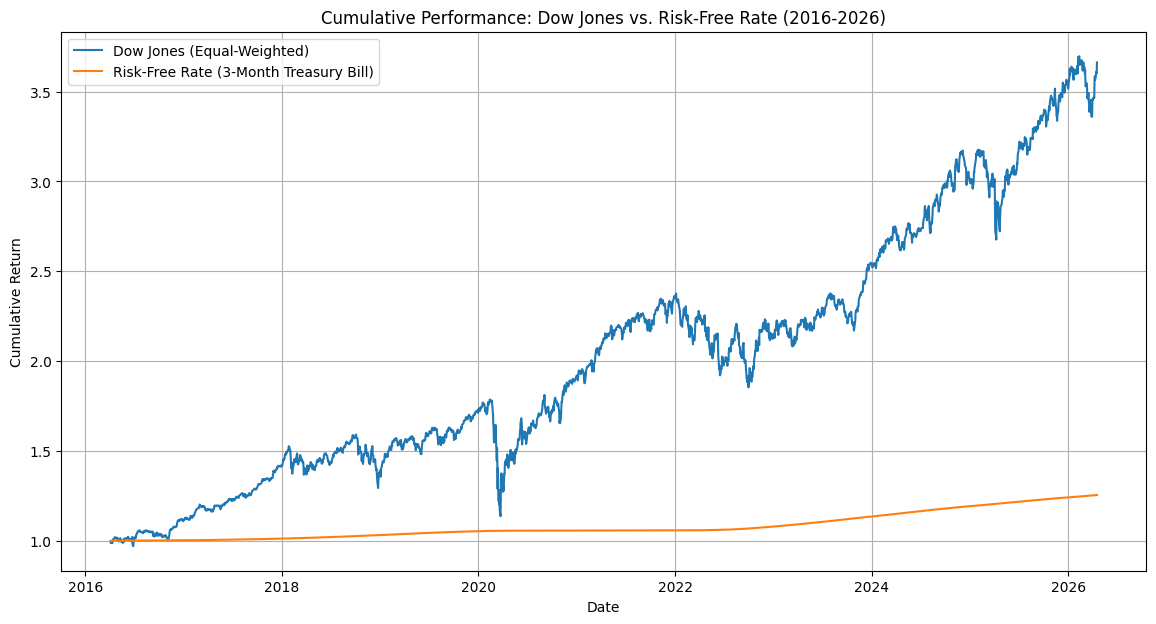

In [26]:
# Calculate daily returns for the Dow Jones (mean of all prices)
djia_daily_ret = prices.mean(axis=1).pct_change().dropna()

# Align risk-free rate to the same index as DJIA returns
rf_daily_aligned = rf_daily.reindex(djia_daily_ret.index).fillna(method='ffill')

# Calculate cumulative returns
cum_djia_ret = (1 + djia_daily_ret).cumprod()
cum_rf_ret = (1 + rf_daily_aligned).cumprod()

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(cum_djia_ret, label='Dow Jones (Equal-Weighted)')
plt.plot(cum_rf_ret, label='Risk-Free Rate (3-Month Treasury Bill)')
plt.title('Cumulative Performance: Dow Jones vs. Risk-Free Rate (2016-2026)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
## ---------------- STAGE 2 -------------------------##
# Cross-sectional per-stock momentum signals

rets = prices.pct_change()

mom_12_1 = prices.shift(21) / prices.shift(252) - 1
mom_6_1  = prices.shift(21) / prices.shift(126) - 1
mom_3_1  = prices.shift(21) / prices.shift(63)  - 1
vol_60   = rets.rolling(60).std() * np.sqrt(252)
ma_cross = prices.rolling(50).mean() / prices.rolling(200).mean() - 1

X_panel = pd.concat({
    'mom_12_1': mom_12_1.stack(),
    'mom_6_1':  mom_6_1.stack(),
    'mom_3_1':  mom_3_1.stack(),
    'vol_60':   vol_60.stack(),
    'ma_cross': ma_cross.stack(),
}, axis=1).replace([np.inf, -np.inf], np.nan)

# Target: next MONTH return — matches momentum signal horizon
fwd_ret = (prices.shift(-21) / prices - 1).stack()
Xy2 = X_panel.join(fwd_ret.rename('target')).dropna()

# Sample monthly to avoid overlapping return labels in training
monthly_dates = Xy2.index.get_level_values(0).unique().sort_values()
monthly_dates = monthly_dates[::21]   # every ~1 month
Xy2 = Xy2[Xy2.index.get_level_values(0).isin(monthly_dates)]

feat_cols = ['mom_12_1', 'mom_6_1', 'mom_3_1', 'vol_60', 'ma_cross']
X2 = Xy2[feat_cols]
y2 = Xy2['target']

dates2  = Xy2.index.get_level_values(0).unique().sort_values()
cutoff2 = dates2[int(len(dates2) * 0.70)]

X2_train = X2[Xy2.index.get_level_values(0) <  cutoff2]
y2_train = y2[Xy2.index.get_level_values(0) <  cutoff2]
X2_test  = X2[Xy2.index.get_level_values(0) >= cutoff2]
y2_test  = y2[Xy2.index.get_level_values(0) >= cutoff2]

scaler2     = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

ridge2 = RidgeCV(alphas=np.logspace(-3, 2, 30), cv=5).fit(X2_train_sc, y2_train)

coef_df2 = pd.Series(ridge2.coef_, index=feat_cols)
print(f"Ridge λ chosen: {ridge2.alpha_:.6f}")
print(f"OOS R\u00b2: {ridge2.score(X2_test_sc, y2_test):.6f}")
print("\nCoefficients:")
print(coef_df2.round(6))


Ridge λ chosen: 100.000000
OOS R²: 0.015422

Coefficients:
mom_12_1   -0.002995
mom_6_1    -0.004017
mom_3_1    -0.000106
vol_60      0.011649
ma_cross    0.008579
dtype: float64


Train obs: 1574  |  Test obs: 699  |  Cutoff: 2023-07-06

── In-sample  (2016-2022) ──────────────────────────────
  Ann. return         -0.48%
  Ann. volatility     18.15%
  Sharpe             -0.021
  Sortino            -0.040
  Max drawdown       -36.97%
  Calmar             -0.013
  Skewness            0.084
  Kurtosis            1.986

── Out-of-sample (2023-2026) ──────────────────────────────
  Ann. return          2.61%
  Ann. volatility     16.96%
  Sharpe             -0.032
  Sortino             0.222
  Max drawdown       -23.76%
  Calmar              0.110
  Skewness           -0.076
  Kurtosis            1.935

── Buy-and-hold (2016-2022) ──────────────────────────────
  Ann. return         14.23%
  Ann. volatility     20.07%
  Sharpe              0.687
  Sortino             0.839
  Max drawdown       -34.67%
  Calmar              0.411
  Skewness           -0.449
  Kurtosis           16.632

── Buy-and-hold (2023-2026) ──────────────────────────────
  Ann. return         2

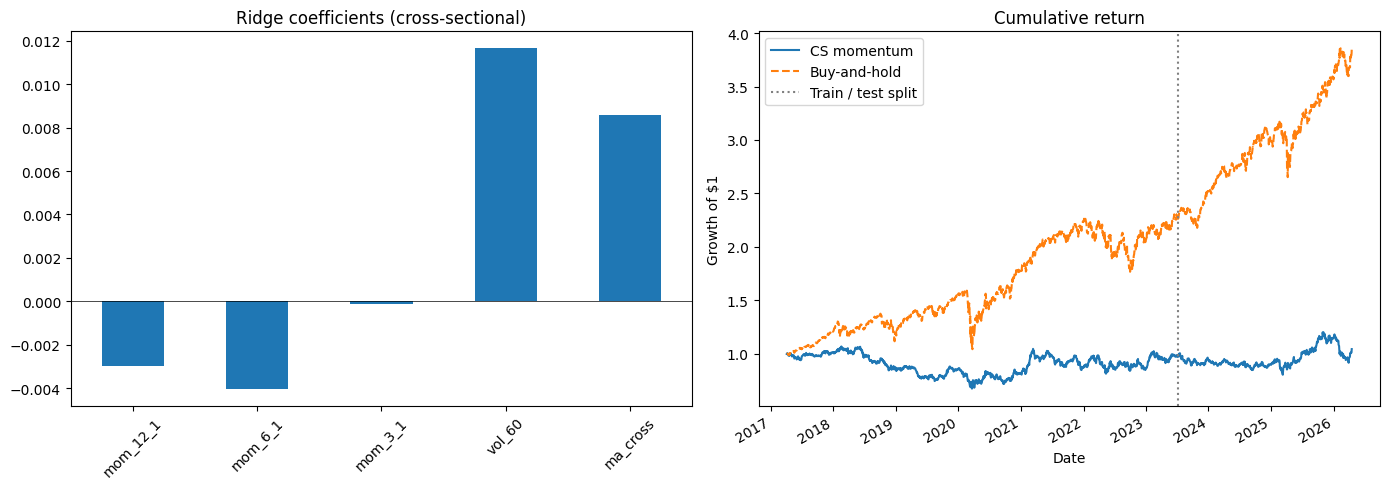

In [28]:
# ── Score all stocks and build cross-sectional long/short portfolio ───────
X2_all = X_panel.replace([np.inf, -np.inf], np.nan).dropna()
X2_all_sc  = scaler2.transform(X2_all[feat_cols])
scores2    = pd.Series(ridge2.predict(X2_all_sc), index=X2_all.index)
score_mat  = scores2.unstack()   # date x ticker

# Mask non-constituents
score_mat = score_mat.where(constituent_map.reindex(score_mat.index))

# Resample to monthly, ffill to daily — rebalance once a month
score_daily = score_mat.resample('ME').last().reindex(score_mat.index).ffill()

# Rank cross-sectionally: long top 20%, short bottom 20%
ranks2   = score_daily.rank(axis=1, pct=True)
long_w2  =  (ranks2 >= 0.80).div((ranks2 >= 0.80).sum(axis=1).replace(0, np.nan), axis=0)
short_w2 = -(ranks2 <= 0.20).div((ranks2 <= 0.20).sum(axis=1).replace(0, np.nan), axis=0)
weights2 = (long_w2 + short_w2).fillna(0)

# Signal on t, trade on t+1
asset_rets2 = prices.pct_change()
port_ret2   = (weights2.shift(1) * asset_rets2).sum(axis=1, min_count=1).dropna()

# Transaction costs: 10 bps per trade
turnover2 = weights2.diff().abs().sum(axis=1)
port_ret2 = port_ret2 - turnover2.reindex(port_ret2.index).fillna(0) * 0.001

ret2_train = port_ret2[port_ret2.index <  cutoff2]
ret2_test  = port_ret2[port_ret2.index >= cutoff2]
bh2        = asset_rets2.mean(axis=1).reindex(port_ret2.index)

print(f"Train obs: {len(ret2_train)}  |  Test obs: {len(ret2_test)}  |  Cutoff: {cutoff2.date()}")

def metrics(ret, label):
    if len(ret) == 0:
        print(f"\n── {label}: no data ──")
        return
    excess  = ret - rf_daily.reindex(ret.index).fillna(0)
    ann_ret = (1 + ret).prod() ** (252 / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe  = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    down    = ret[ret < 0].std() * np.sqrt(252)
    sortino = ann_ret / down if down > 0 else np.nan
    cum     = (1 + ret).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    print(f"\n── {label} ──────────────────────────────")
    print(f"  Ann. return      {ann_ret*100:>8.2f}%")
    print(f"  Ann. volatility  {ann_vol*100:>8.2f}%")
    print(f"  Sharpe           {sharpe:>8.3f}")
    print(f"  Sortino          {sortino:>8.3f}")
    print(f"  Max drawdown     {max_dd*100:>8.2f}%")
    print(f"  Calmar           {calmar:>8.3f}")
    print(f"  Skewness         {ret.skew():>8.3f}")
    print(f"  Kurtosis         {ret.kurt():>8.3f}")

metrics(ret2_train, "In-sample  (2016-2022)")
metrics(ret2_test,  "Out-of-sample (2023-2026)")
metrics(bh2[bh2.index <  cutoff2], "Buy-and-hold (2016-2022)")
metrics(bh2[bh2.index >= cutoff2], "Buy-and-hold (2023-2026)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
coef_df2.plot(kind="bar", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Ridge coefficients (cross-sectional)")
axes[0].tick_params(axis="x", rotation=45)
(1 + port_ret2).cumprod().plot(ax=axes[1], label="CS momentum")
(1 + bh2).cumprod().plot(ax=axes[1], linestyle="--", label="Buy-and-hold")
axes[1].axvline(cutoff2, color="gray", linestyle=":", label="Train / test split")
axes[1].set_title("Cumulative return")
axes[1].set_ylabel("Growth of $1")
axes[1].legend()
plt.tight_layout()
plt.show()
